In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

In [4]:
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [5]:
print(f"Dataset loaded!")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"\n🔎 Column Names:\n{list(df.columns)}")
df.head()

Dataset loaded!
Rows: 7043, Columns: 21

🔎 Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
print("Shape:", df.shape)
print("\nColumn Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (7043, 21)

Column Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract     

In [8]:
# Cell 4 — Data Cleaning

# Fix 1: Convert TotalCharges to number
# errors='coerce' turns blank spaces into NaN so we can find and drop them
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many NaN values appeared after conversion
print("Null values in TotalCharges after conversion:", df['TotalCharges'].isnull().sum())

# Drop those rows — they are customers with 0 tenure (just joined, no charges yet)
df.dropna(subset=['TotalCharges'], inplace=True)

# Fix 2: Convert Churn to 0 and 1
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Confirm everything is fixed
print("\nUpdated Shape:", df.shape)
print("\nTotalCharges dtype:", df['TotalCharges'].dtype)
print("Churn dtype:", df['Churn'].dtype)
print("\nChurn unique values:", df['Churn'].unique())

Null values in TotalCharges after conversion: 11

Updated Shape: (7032, 21)

TotalCharges dtype: float64
Churn dtype: int64

Churn unique values: [0 1]


In [9]:
# Cell 5 — Basic Statistics

# Overall churn rate
churn_rate = df['Churn'].mean() * 100
print("Overall Churn Rate:", round(churn_rate, 2), "%")

# Revenue at risk from churned customers
revenue_at_risk = df[df['Churn'] == 1]['MonthlyCharges'].sum()
print("Monthly Revenue at Risk: $", round(revenue_at_risk, 2))

# Average tenure of churned vs retained customers
avg_tenure = df.groupby('Churn')['tenure'].mean()
print("\nAverage Tenure (months):")
print("Retained customers:", round(avg_tenure[0], 1), "months")
print("Churned customers:", round(avg_tenure[1], 1), "months")

# Average monthly charges of churned vs retained
avg_charges = df.groupby('Churn')['MonthlyCharges'].mean()
print("\nAverage Monthly Charges:")
print("Retained customers: $", round(avg_charges[0], 2))
print("Churned customers: $", round(avg_charges[1], 2))

Overall Churn Rate: 26.58 %
Monthly Revenue at Risk: $ 139130.85

Average Tenure (months):
Retained customers: 37.7 months
Churned customers: 18.0 months

Average Monthly Charges:
Retained customers: $ 61.31
Churned customers: $ 74.44


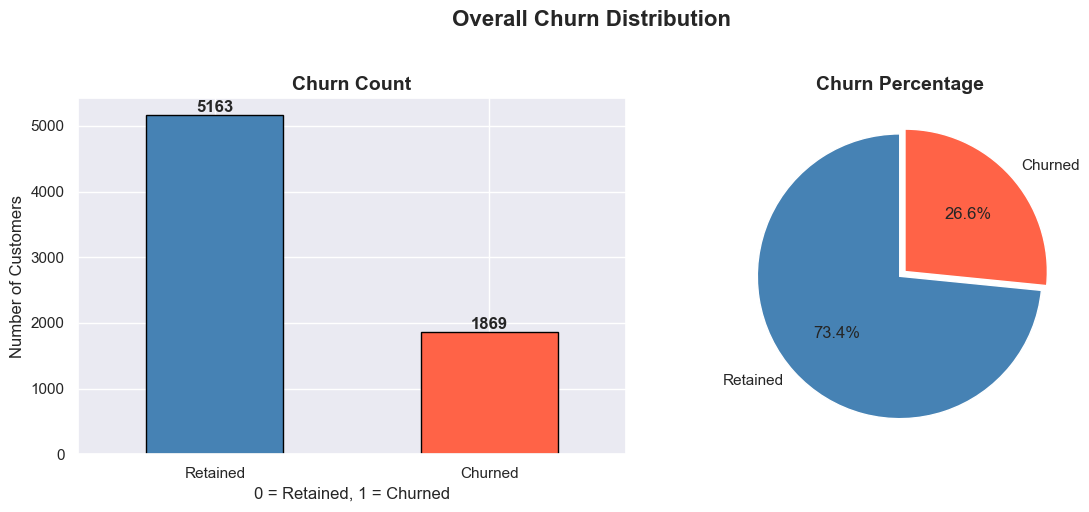

Chart saved.


In [10]:
# Cell 6 — Churn Distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1 — Count of churned vs retained
df['Churn'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color=['steelblue', 'tomato'],
    edgecolor='black'
)
axes[0].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('0 = Retained, 1 = Churned')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticklabels(['Retained', 'Churned'], rotation=0)

# Add value labels on bars
for p in axes[0].patches:
    axes[0].annotate(str(p.get_height()),
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Chart 2 — Percentage pie chart
axes[1].pie(
    df['Churn'].value_counts(),
    labels=['Retained', 'Churned'],
    autopct='%1.1f%%',
    colors=['steelblue', 'tomato'],
    startangle=90,
    explode=(0, 0.05)
)
axes[1].set_title('Churn Percentage', fontsize=14, fontweight='bold')

plt.suptitle('Overall Churn Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved.")

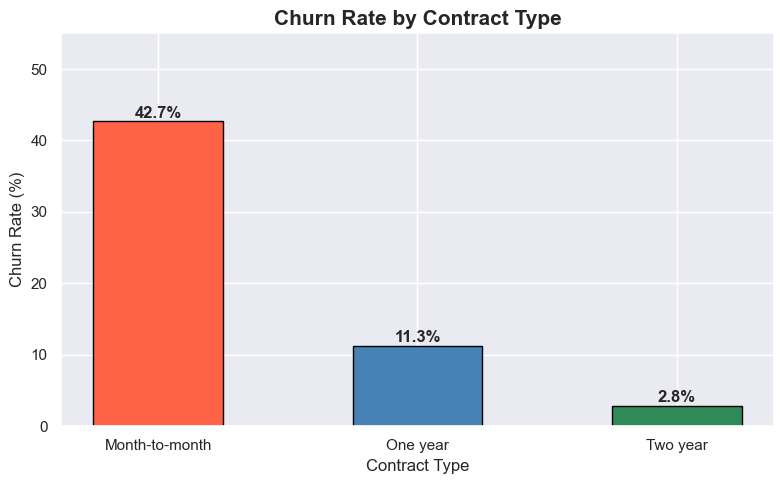

Churn Rate by Contract Type:
  Month-to-month: 42.7%
  One year: 11.3%
  Two year: 2.8%


In [11]:
# Cell 7 — Churn by Contract Type

contract_churn = df.groupby('Contract')['Churn'].mean() * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(
    contract_churn.index,
    contract_churn.values,
    color=['tomato', 'steelblue', 'seagreen'],
    edgecolor='black',
    width=0.5
)

# Add percentage labels on top of each bar
for bar, val in zip(bars, contract_churn.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center',
        fontweight='bold',
        fontsize=12
    )

plt.title('Churn Rate by Contract Type', fontsize=15, fontweight='bold')
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.ylim(0, 55)
plt.tight_layout()
plt.savefig('churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the exact numbers
print("Churn Rate by Contract Type:")
for contract, rate in contract_churn.items():
    print(f"  {contract}: {rate:.1f}%")

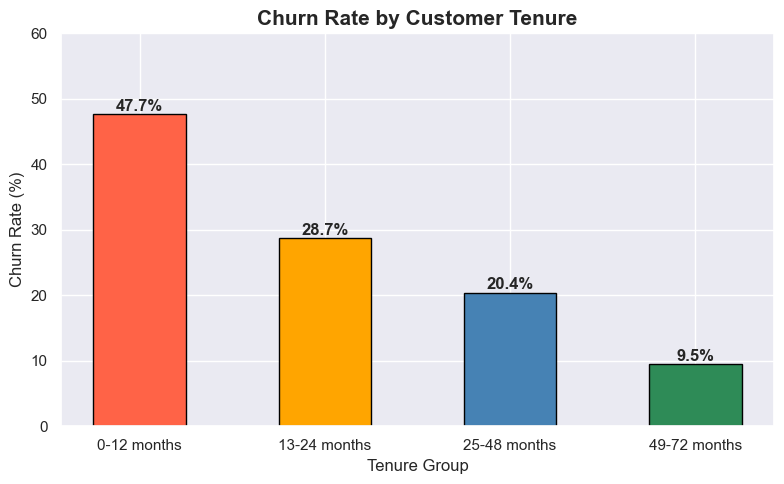

Churn Rate by Tenure Group:
  0-12 months: 47.7%
  13-24 months: 28.7%
  25-48 months: 20.4%
  49-72 months: 9.5%


In [12]:
# Cell 8 — Churn by Tenure Group

# Create tenure groups
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 months', '13-24 months', '25-48 months', '49-72 months']
)

tenure_churn = df.groupby('tenure_group', observed=True)['Churn'].mean() * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(
    tenure_churn.index,
    tenure_churn.values,
    color=['tomato', 'orange', 'steelblue', 'seagreen'],
    edgecolor='black',
    width=0.5
)

for bar, val in zip(bars, tenure_churn.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center',
        fontweight='bold',
        fontsize=12
    )

plt.title('Churn Rate by Customer Tenure', fontsize=15, fontweight='bold')
plt.xlabel('Tenure Group', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.ylim(0, 60)
plt.tight_layout()
plt.savefig('churn_by_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

print("Churn Rate by Tenure Group:")
for group, rate in tenure_churn.items():
    print(f"  {group}: {rate:.1f}%")

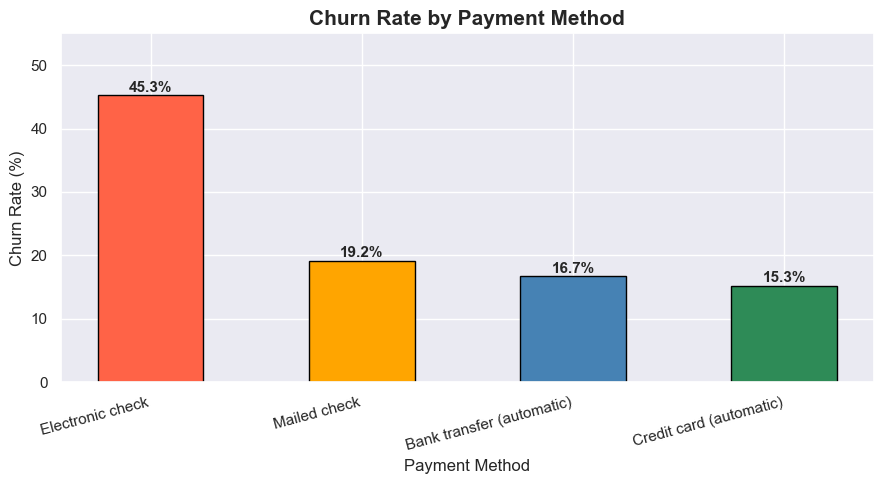

Churn Rate by Payment Method:
  Electronic check: 45.3%
  Mailed check: 19.2%
  Bank transfer (automatic): 16.7%
  Credit card (automatic): 15.3%


In [13]:
# Cell 9 — Churn by Payment Method

payment_churn = df.groupby('PaymentMethod')['Churn'].mean() * 100
payment_churn = payment_churn.sort_values(ascending=False)

plt.figure(figsize=(9, 5))
bars = plt.bar(
    payment_churn.index,
    payment_churn.values,
    color=['tomato', 'orange', 'steelblue', 'seagreen'],
    edgecolor='black',
    width=0.5
)

for bar, val in zip(bars, payment_churn.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center',
        fontweight='bold',
        fontsize=11
    )

plt.title('Churn Rate by Payment Method', fontsize=15, fontweight='bold')
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xticks(rotation=15, ha='right')
plt.ylim(0, 55)
plt.tight_layout()
plt.savefig('churn_by_payment.png', dpi=150, bbox_inches='tight')
plt.show()

print("Churn Rate by Payment Method:")
for method, rate in payment_churn.items():
    print(f"  {method}: {rate:.1f}%")

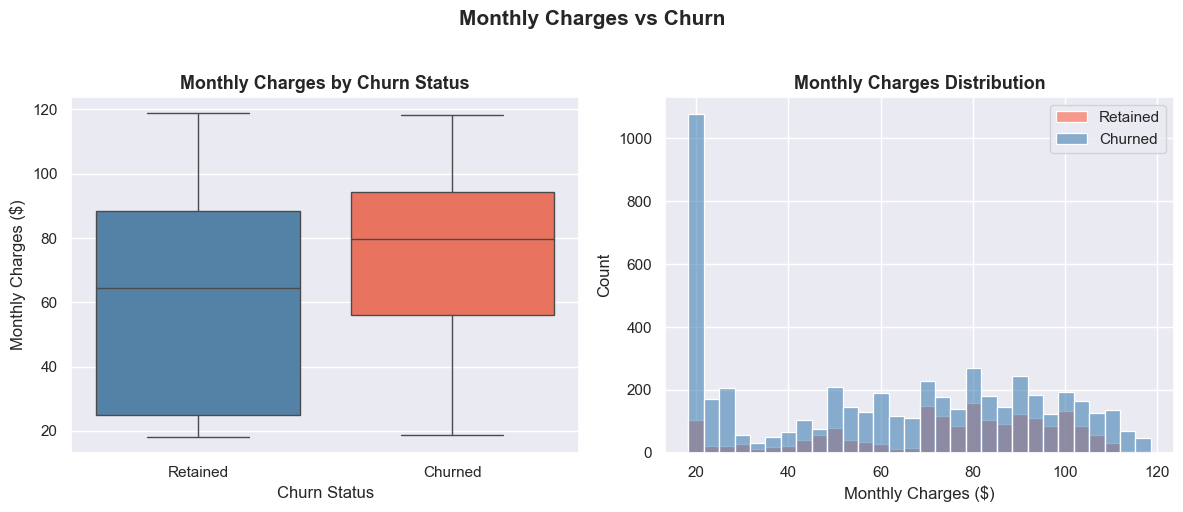

Average Monthly Charges:
        count   mean    std    min    25%    50%    75%     max
Churn                                                          
0      5163.0  61.31  31.09  18.25  25.10  64.45  88.48  118.75
1      1869.0  74.44  24.67  18.85  56.15  79.65  94.20  118.35


In [15]:
# Cell 10 — Monthly Charges Distribution by Churn (fixed)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1 — Box plot (fixed for newer Seaborn)
sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df,
    hue='Churn',
    palette={0: 'steelblue', 1: 'tomato'},
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Monthly Charges by Churn Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn Status')
axes[0].set_ylabel('Monthly Charges ($)')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Retained', 'Churned'])

# Chart 2 — Distribution overlay
sns.histplot(
    data=df,
    x='MonthlyCharges',
    hue='Churn',
    bins=30,
    palette={0: 'steelblue', 1: 'tomato'},
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_title('Monthly Charges Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('Count')
axes[1].legend(labels=['Retained', 'Churned'])

plt.suptitle('Monthly Charges vs Churn', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('churn_by_charges.png', dpi=150, bbox_inches='tight')
plt.show()

print("Average Monthly Charges:")
print(df.groupby('Churn')['MonthlyCharges'].describe().round(2))

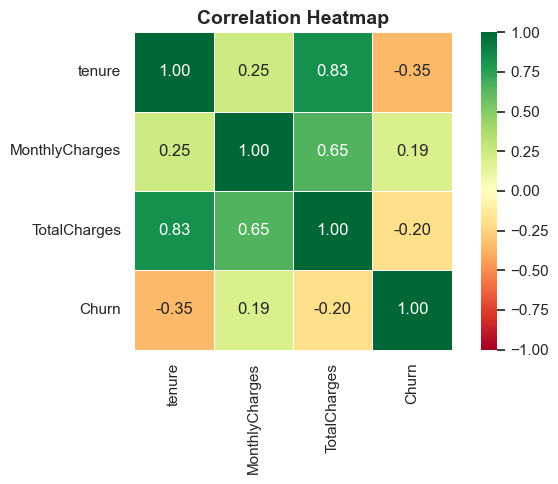

In [16]:
# Cell 11 — Correlation Heatmap

# Select only numeric columns
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

# Calculate correlation
corr = numeric_df.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5,
    linecolor='white',
    square=True,
    vmin=-1,
    vmax=1
)

plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Cell 12 — Save cleaned dataset for SQL

df.to_csv('telco_churn_cleaned.csv', index=False)
print("Cleaned dataset saved.")
print("Shape:", df.shape)
print("Columns:", list(df.columns))

Cleaned dataset saved.
Shape: (7032, 22)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_group']


In [4]:
df = pd.read_csv('telco_churn_cleaned.csv')
print(list(df.columns))

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_group']
